In [631]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

In [632]:
data = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
data.data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [633]:
X = data.data
X = X / 255.0
y = data.target

In [634]:
def display_image(index, X, y):
    print(f'\nLabel: {y[index]}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.show()


Label: 4



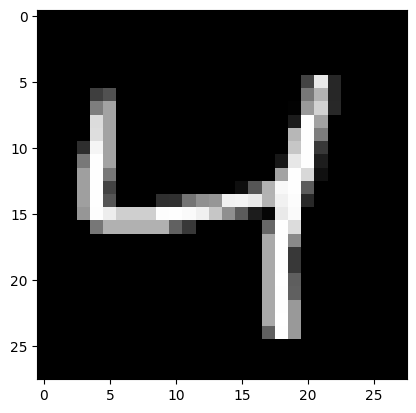

In [635]:
display_image(2, X, y)

In [636]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self, output_gradient, learning_rate, batch_size):
        pass

In [637]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size
        self.weights = np.random.randn(self.output_size, self.input_size)
        self.baises = np.zeros((self.output_size, 1))

    def forward(self, input):
        self.input = input
        return self.weights.dot(self.input) + self.baises

    def backward(self, output_gradient, learning_rate):
        self.dW = output_gradient.dot(self.input.T)
        self.dB = output_gradient
        self.dX = self.weights.T.dot(output_gradient)

        self.weights -= self.dW * learning_rate
        self.baises -= self.dB * learning_rate
        return self.dX

In [652]:
class Activation(Layer):
    def __init__(self, activation_function, activation_prime):
        self.activation_function = activation_function
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation_function(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [653]:
class Tanh(Activation):
    def __init__(self):
        tanh = lambda x: np.tanh(x)
        tanh_prime = lambda x: 1 - np.tanh(x)**2
        super().__init__(tanh, tanh_prime)

In [654]:
class ReLU(Activation):
    def __init__(self):
        relu = lambda x: np.fmax(0, x)
        relu_prime = lambda x: (x > 0).astype(float)
        super().__init__(relu, relu_prime)

In [655]:
class Softmax(Activation):
    def __init__(self):
        softmax = lambda x: np.exp(x - np.max(x)) / np.sum(np.exp(x - np.max(x)))
        softmax_prime = lambda x: 1
        super().__init__(softmax, softmax_prime)

In [642]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-9))

def cross_entropy_prime(y_true, y_pred):
    return y_pred - y_true

def accuracy(y_true, y_pred):
    correct = 0
    for yt, yp in zip(y_true, y_pred):
        if np.argmax(yt) == np.argmax(yp): correct += 1
    return correct / y_true.shape[0]
    

In [643]:
def one_hot_encode(data):
    one_hot = []
    for d in data:
        one_hot.append(np.zeros((10, 1)))
        one_hot[-1][int(d)] = 1
    return np.array(one_hot)

In [644]:
X = X.reshape(70000, 784, 1)
y_one_hot = one_hot_encode(y)

In [645]:
X.shape, y_one_hot.shape

((70000, 784, 1), (70000, 10, 1))

In [656]:
class NeuralNetwork:
    def __init__(self, network):
        self.network = network

    def predict(data):
        output = data
        for layer in self.network:
            output = layer.forward(output)
        return output

    def train(self, X, y, learning_rate=0.1, epoch=16):
        for i in range(epoch):
            error = 0
            correct = 0
            for x, y_true in zip(X, y):
                output = x
                for layer in self.network:
                    output = layer.forward(output)
        
                loss = cross_entropy(y_true, output)
                error += loss
                if np.argmax(y_true) == np.argmax(output): correct += 1
                gradient = cross_entropy_prime(y_true, output)
                for layer in reversed(self.network):
                    gradient = layer.backward(gradient, learning_rate)
            print(f"Epoch: {i + 1}/{epoch} | Cross Entropy Loss: {error / y.shape[0]} | Accuracy: {correct / y.shape[0]}")

In [657]:
NN = NeuralNetwork([
    Dense(784, 16),
    ReLU(),
    Dense(16, 16),
    ReLU(),
    Dense(16, 10),
    Softmax(),
])

In [658]:
NN.train(X, y_one_hot, learning_rate=.01, epoch=16)

Epoch: 1/16 | Cross Entropy Loss: 1.4872049238468281 | Accuracy: 0.4281285714285714
Epoch: 2/16 | Cross Entropy Loss: 0.8270990209855847 | Accuracy: 0.7302142857142857
Epoch: 3/16 | Cross Entropy Loss: 0.5349253905071181 | Accuracy: 0.8558
Epoch: 4/16 | Cross Entropy Loss: 0.44775889034660254 | Accuracy: 0.8794428571428572
Epoch: 5/16 | Cross Entropy Loss: 0.3964762451365811 | Accuracy: 0.8948285714285714
Epoch: 6/16 | Cross Entropy Loss: 0.36409259407902317 | Accuracy: 0.9045571428571428
Epoch: 7/16 | Cross Entropy Loss: 0.3396868058729656 | Accuracy: 0.9104857142857142
Epoch: 8/16 | Cross Entropy Loss: 0.322050192607081 | Accuracy: 0.915
Epoch: 9/16 | Cross Entropy Loss: 0.30592678384938454 | Accuracy: 0.9195
Epoch: 10/16 | Cross Entropy Loss: 0.2944000140175018 | Accuracy: 0.9224571428571429
Epoch: 11/16 | Cross Entropy Loss: 0.2860481949368511 | Accuracy: 0.9253571428571429
Epoch: 12/16 | Cross Entropy Loss: 0.277193616075863 | Accuracy: 0.9276
Epoch: 13/16 | Cross Entropy Loss: 0.

In [659]:
def display_image_prediction(index, X, y, network):
    output = X[index]
    for layer in network:
        output = layer.forward(output)
    print(f'\nLabel: {y[index]} | Predicted: {np.argmax(output)}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image)
    plt.show()


Label: 3 | Predicted: 3



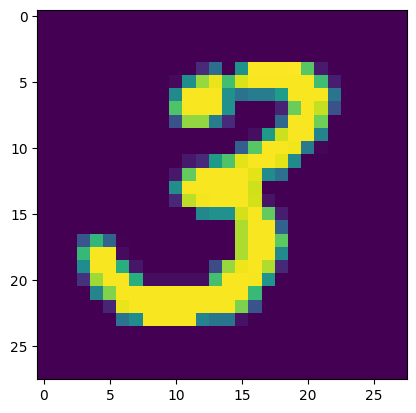

In [660]:
display_image_prediction(255, X, y, network)